<a href="https://colab.research.google.com/github/Peter-obi/random_scripts/blob/main/Intro_to_pytorch_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch

In [ ]:
z = torch.zeros(5, 3)
print (z)
print(z.dtype)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
torch.float32


In [ ]:
i = torch.ones((5, 3), dtype=torch.int16) #get tensors if intergers instead float32 is default
print(i)

tensor([[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]], dtype=torch.int16)


In [ ]:
torch.manual_seed(42)
r1 = torch.rand(2, 2)
print('A random tensor: ')
print(r1)

r2 = torch.rand(2,2)
print('\nA different random tensor')
print(r2)

torch.manual_seed(42)
r3 = torch.rand(2,2)
print('\nShould match r1:')
print(r3)

A random tensor: 
tensor([[0.8823, 0.9150],
        [0.3829, 0.9593]])

A different random tensor
tensor([[0.3904, 0.6009],
        [0.2566, 0.7936]])

Should match r1:
tensor([[0.8823, 0.9150],
        [0.3829, 0.9593]])


In [ ]:
ones = torch.ones(2, 3)
print(ones)

twos = torch.ones(2, 3) * 2 #element is multiplied by 2
print(twos)

threes = ones + twos #elementwise addition -> must have similar shapes, same dimensions as input tensors
print(threes)
print(threes.shape)

r1 = torch.rand(2, 3)
r2 = torch.rand(3, 2)
r3 = r1 + r2

tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[2., 2., 2.],
        [2., 2., 2.]])
tensor([[3., 3., 3.],
        [3., 3., 3.]])
torch.Size([2, 3])


RuntimeError: The size of tensor a (3) must match the size of tensor b (2) at non-singleton dimension 1

In [ ]:
r1 = torch.rand(2, 3)
r2 = torch.rand(3, 2).reshape(2,3)
r3 = r1 + r2
r3

tensor([[1.1824, 1.4056, 0.3719],
        [0.8969, 0.6284, 0.6407]])

In [ ]:
r = torch.rand(2, 2) - 0.5 * 2
print('A random matrix, r:')
print(r)

#some mathematical operations
print('\nAbsolute value of r:')
print(torch.abs(r))

print('\nInverse sine of r: ')
print(torch.asin(r))

print('\nDeterminant of r: ')
print(torch.det(r))
print('\nSingular Value decomposition of r: ')
print(torch.svd(r))

print('\nAverage and standard deviation of r: ')
print(torch.std_mean(r))
print('\nMaximum value of r: ')
print(torch.max(r))

A random matrix, r:
tensor([[-0.4528, -0.9938],
        [-0.0484, -0.9247]])

Absolute value of r:
tensor([[0.4528, 0.9938],
        [0.0484, 0.9247]])

Inverse sine of r: 
tensor([[-0.4699, -1.4597],
        [-0.0485, -1.1803]])

Determinant of r: 
tensor(0.3706)

Singular Value decomposition of r: 
torch.return_types.svd(
U=tensor([[ 0.7666,  0.6421],
        [ 0.6421, -0.7666]]),
S=tensor([1.4074, 0.2633]),
V=tensor([[-0.2687, -0.9632],
        [-0.9632,  0.2687]]))

Average and standard deviation of r: 
(tensor(0.4421), tensor(-0.6050))

Maximum value of r: 
tensor(-0.0484)


##Simple Pytorch model

In [ ]:
import torch
import torch.nn as nn #for torch.nn.Module, the parent object for pytorch models
import torch.nn.functional as F #for the activation functiion

In [ ]:
class LeNet(nn.Module):

  def __init__(self):
    super(LeNet, self). __init__()
    #1 input image channel (black and white), 6 output channels, 3x3 square convolution kerenel
    self.conv1 = nn.Conv2d(1, 6, 3)
    self.conv2 = nn.Conv2d(6, 16, 3)
    #an affine operation: y = Wx + b
    self.fc1 = nn.Linear(16 * 6 * 6, 120) #6*6 from image dimension
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
    #Max pooling over a (2,2) window
    x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
    #if the size is a square you can only specify a single number
    x = F.max_pool2d(F.relu(self.conv2(x)), 2)
    x = x.view(-1, self.num_flat_features(x))
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

  def num_flat_features(self, x):
    size = x.size()[1:] #all dimensions except the batch dimension
    num_features = 1
    for s in size:
      num_features *=s
    return num_features

In [ ]:
net = LeNet()
print(net)

input = torch.randn(1, 1, 32, 32)
print('\nImage batch shape: ')
print(input.shape)

output = net(input)
print('\nRaw output: ')
print(output)
print(output.shape)

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=576, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Image batch shape: 
torch.Size([1, 1, 32, 32])

Raw output: 
tensor([[-0.0537,  0.0304,  0.1401,  0.1218,  0.0420,  0.0939, -0.0051,  0.0381,
          0.0730,  0.1264]], grad_fn=<AddmmBackward0>)
torch.Size([1, 10])


##Dataset and DataLoader

In [ ]:
%matplotlib inline

import torch
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim

In [ ]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

In [ ]:
trainset = torchvision.datasets.CIFAR10(root = './data', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:02<00:00, 57.9MB/s]


In [ ]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True, num_workers=2)

 deer  car deerhorse


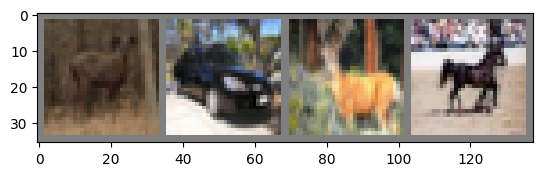

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img):
  img = img/2 + 0.5 #unnormalize
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))

#get some random images
dataiter = iter(trainloader)
images, labels = next(dataiter)

#show images
imshow(torchvision.utils.make_grid(images))
print(''.join('%5s' % classes[labels[j]] for j in range(4)))

In [ ]:
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4, shuffle=False, num_workers=2)

In [ ]:
class Net(nn.Module):

  def __init__(self):
    super(Net, self). __init__()
    self.conv1 = nn.Conv2d(3, 6, 5)
    self.pool = nn.MaxPool2d(2, 2)
    self.conv2 = nn.Conv2d(6, 16, 5)
    self.fc1 = nn.Linear(16 * 5 * 5, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = x.view(-1, 16 * 5 * 5)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

net = Net()

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [ ]:
for epoch in range(2):

  running_loss = 0.0
  for i, data in enumerate(trainloader, 0):
    inputs, labels = data #get inputs

    optimizer.zero_grad #zero the parmaeter gradients so we can clear the gradients after each batch

    #forward + backward + optimize
    outputs = net(inputs)
    loss = criterion(outputs, labels)
    loss.backward() #calculate gradients of the loss with respect to every single parameter
    optimizer.step() #use these gradients calculated to update the weights and biases

    #print statistics
    running_loss += loss.item() #use item to get isngle python number not tensor
    if i % 2000 == 1999: #print every 2000 mini-batches
      print('[%d, %5d] loss: %.3f' % (epoch + 1, i + 1, running_loss / 2000))
      running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 13164.275
[1,  4000] loss: 96.623
[1,  6000] loss: 192.029
[1,  8000] loss: 272.131
[1, 10000] loss: 343.436
[1, 12000] loss: 491.255
[2,  2000] loss: 585.962
[2,  4000] loss: 756.662
[2,  6000] loss: 727.198
[2,  8000] loss: 1071.094
[2, 10000] loss: 892.262
[2, 12000] loss: 1149.152
Finished Training


In [ ]:
correct = 0
total = 0
with torch.no_grad():
  for data in testloader:
    images, labels = data
    outputs = net(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (100 * correct/total))

Accuracy of the network on the 10000 test images: 10 %


#Pytorch_tensors_indepth

In [3]:
x = torch.empty(3, 4)
print(type(x))
print(x)

<class 'torch.Tensor'>
tensor([[2.2931e-25, 4.5394e-41, 2.2931e-25, 4.5394e-41],
        [3.7670e-36, 4.5394e-41, 3.8964e-36, 4.5394e-41],
        [1.3371e-25, 4.5394e-41, 3.8964e-36, 4.5394e-41]])
